In [ ]:
!pip install tensorflow pandas scikit-learn numpy

import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, Conv1D, MaxPooling1D, GlobalMaxPooling1D
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling1D, concatenate
from tensorflow.keras.layers import SpatialDropout1D, GaussianNoise, Add
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2


In [ ]:
# MUStARD++ for sarcasm & emotion
mustard_df = pd.read_csv("/content/mustard++_text.csv")
mustard_df = mustard_df[['SENTENCE', 'Sarcasm', 'Explicit_Emotion']]
mustard_df['Sarcasm'] = mustard_df['Sarcasm'].fillna(0)
mustard_df['Explicit_Emotion'] = mustard_df['Explicit_Emotion'].fillna('neutral')

# Jigsaw for toxicity
jigsaw_df = pd.read_csv("/content/data.csv")
jigsaw_df = jigsaw_df[['comment_text', 'target']]

print("MUStARD++ sample:", mustard_df.head())
print("Jigsaw sample:", jigsaw_df.head())


MUStARD++ sample:                                             SENTENCE  Sarcasm Explicit_Emotion
0  Well, I'm sure that, uh, you...\nhave a lot of...      0.0          neutral
1                                        Who was he?      0.0          neutral
2    His name is Ron.\nI met him at my prayer group.      0.0          neutral
3          How long have you been involved with him?      0.0          neutral
4                                      A few months.      0.0          neutral
Jigsaw sample:                                         comment_text    target
0               haha you guys are a bunch of losers.  0.893617
1  Yet call out all Muslims for the acts of a few...  0.912500
2  This bitch is nuts. Who would read a book by a...  0.830769
3                                   You're an idiot.  0.968750
4  Who cares!? Stark trek and Star Wars fans are ...  0.900000


In [ ]:
def encode_labels(labels):
    le = LabelEncoder()
    return le.fit_transform(labels), le

def preprocess_texts(texts, tokenizer=None, max_len=50, num_words=20000):
    if tokenizer is None:
        tokenizer = Tokenizer(num_words=num_words, oov_token="<OOV>")
        tokenizer.fit_on_texts(texts)
    sequences = tokenizer.texts_to_sequences(texts)
    padded = pad_sequences(sequences, maxlen=max_len, padding='post')
    return padded, tokenizer


In [ ]:
# --- MUStARD++ ---
X_mustard = mustard_df['SENTENCE'].astype(str).tolist()
y_sarcasm_m, le_sarcasm = encode_labels(mustard_df['Sarcasm'])
y_emotion_m, le_emotion = encode_labels(mustard_df['Explicit_Emotion'])
y_toxic_m = np.zeros(len(X_mustard))  # synthetic toxicity

# --- Jigsaw ---
X_jigsaw = jigsaw_df['comment_text'].astype(str).tolist()
y_toxic_j = (jigsaw_df['target'] > 0.5).astype(int).values

# Add a few random synthetic sarcasm/ emotion positives to make model harder
np.random.seed(42)
sarcasm_noise = np.random.choice([0,1], size=len(X_jigsaw), p=[0.95,0.05])
emotion_noise = np.random.choice([0,1], size=len(X_jigsaw), p=[0.95,0.05])

y_sarcasm_j = sarcasm_noise
y_emotion_j = emotion_noise

# Combine datasets
X_all = X_mustard + X_jigsaw
y_sarcasm_all = np.concatenate([y_sarcasm_m, y_sarcasm_j])
y_emotion_all = np.concatenate([y_emotion_m, y_emotion_j])
y_toxic_all = np.concatenate([y_toxic_m, y_toxic_j])

# Tokenize
X_seq, tokenizer = preprocess_texts(X_all, max_len=50)

# Train/validation split
X_train, X_val, y_sarcasm_train, y_sarcasm_val, y_emotion_train, y_emotion_val, y_toxic_train, y_toxic_val = train_test_split(
    X_seq,
    y_sarcasm_all,
    y_emotion_all,
    y_toxic_all,
    test_size=0.1,
    random_state=42
)

# Multi-task dictionaries
y_train = {'sarcasm': y_sarcasm_train, 'emotion': y_emotion_train, 'toxicity': y_toxic_train}
y_val = {'sarcasm': y_sarcasm_val, 'emotion': y_emotion_val, 'toxicity': y_toxic_val}


In [ ]:
vocab_size = 20000
embedding_dim = 128
input_length = 50

inputs = Input(shape=(input_length,))
x = Embedding(vocab_size, embedding_dim, input_length=input_length)(inputs)
x = SpatialDropout1D(0.2)(x)
x = GaussianNoise(0.1)(x)

# Multi-kernel conv blocks with residual connections
conv2 = Conv1D(128, 2, activation='relu', kernel_regularizer=l2(0.001), padding='same')(x)
conv3 = Conv1D(128, 3, activation='relu', kernel_regularizer=l2(0.001), padding='same')(x)
conv4 = Conv1D(128, 4, activation='relu', kernel_regularizer=l2(0.001), padding='same')(x)
res = Add()([conv2, conv3, conv4])
res = BatchNormalization()(res)
res = MaxPooling1D(3)(res)

# Global pooling
pool = concatenate([GlobalMaxPooling1D()(res), GlobalAveragePooling1D()(res)])
pool = Dropout(0.5)(pool)

# Dense layers
dense1 = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(pool)
dense1 = Dropout(0.5)(dense1)
dense2 = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(dense1)
dense2 = Dropout(0.5)(dense2)

# Multi-task outputs
sarcasm_output = Dense(1, activation='sigmoid', name='sarcasm')(dense2)
emotion_output = Dense(len(le_emotion.classes_), activation='softmax', name='emotion')(dense2)
toxicity_output = Dense(1, activation='sigmoid', name='toxicity')(dense2)

# Model
complex_cnn = Model(inputs=inputs, outputs=[sarcasm_output, emotion_output, toxicity_output])
complex_cnn.compile(
    optimizer='adam',
    loss={'sarcasm':'binary_crossentropy',
          'emotion':'sparse_categorical_crossentropy',
          'toxicity':'binary_crossentropy'},
    metrics={'sarcasm':'accuracy',
             'emotion':'accuracy',
             'toxicity':'accuracy'}
)

complex_cnn.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 50, 128)   │  2,560,000 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 50, 128)   │          0 │ embedding_6[0][0] │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 50, 128)   │          0 │ spatial_dropout1… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_17 (Conv1D)  │ (None, 50, 128)   │     32,896 │ gaussian_noise[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_18 (Conv1D)  │ (None, 50, 128)   │     49,280 │ gaussian_noise[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_19 (Conv1D)  │ (None, 50, 128)   │     65,664 │ gaussian_noise[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 50, 128)   │          0 │ conv1d_17[0][0],  │
│                     │                   │            │ conv1d_18[0][0],  │
│                     │                   │            │ conv1d_19[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 128)   │        512 │ add[0][0]         │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_16    │ (None, 16, 128)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ max_pooling1d_16… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ max_pooling1d_16… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_20      │ (None, 256)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 256)       │          0 │ concatenate_20[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 256)       │     65,792 │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 256)       │          0 │ dense_11[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 128)       │     32,896 │ dropout_17[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 128)       │          0 │ dense_12[0][0]    │
│ (Dropout)           │                   │            │                 

 Total params: 2,808,588 (10.71 MB)

 Trainable params: 2,808,332 (10.71 MB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
history = complex_cnn.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)


Epoch 1/10
2727/2727 ━━━━━━━━━━━━━━━━━━━━ 241s 88ms/step - emotion_accuracy: 0.8920 - emotion_loss: 0.4564 - loss: 1.8460 - sarcasm_accuracy: 0.9463 - sarcasm_loss: 0.2336 - toxicity_accuracy: 0.5669 - toxicity_loss: 0.6573 - val_emotion_accuracy: 0.8986 - val_emotion_loss: 0.3952 - val_loss: 1.0468 - val_sarcasm_accuracy: 0.9501 - val_sarcasm_loss: 0.2212 - val_toxicity_accuracy: 0.9056 - val_toxicity_loss: 0.2706
Epoch 2/10
2727/2727 ━━━━━━━━━━━━━━━━━━━━ 238s 87ms/step - emotion_accuracy: 0.8995 - emotion_loss: 0.3720 - loss: 1.0007 - sarcasm_accuracy: 0.9483 - sarcasm_loss: 0.2146 - toxicity_accuracy: 0.9032 - toxicity_loss: 0.2752 - val_emotion_accuracy: 0.9152 - val_emotion_loss: 0.3264 - val_loss: 0.8573 - val_sarcasm_accuracy: 0.9501 - val_sarcasm_loss: 0.2046 - val_toxicity_accuracy: 0.9199 - val_toxicity_loss: 0.2229
Epoch 3/10
2727/2727 ━━━━━━━━━━━━━━━━━━━━ 237s 87ms/step - emotion_accuracy: 0.9080 - emotion_loss: 0.3393 - loss: 0.8750 - sarcasm_accuracy: 0.9480 - sarcasm_los

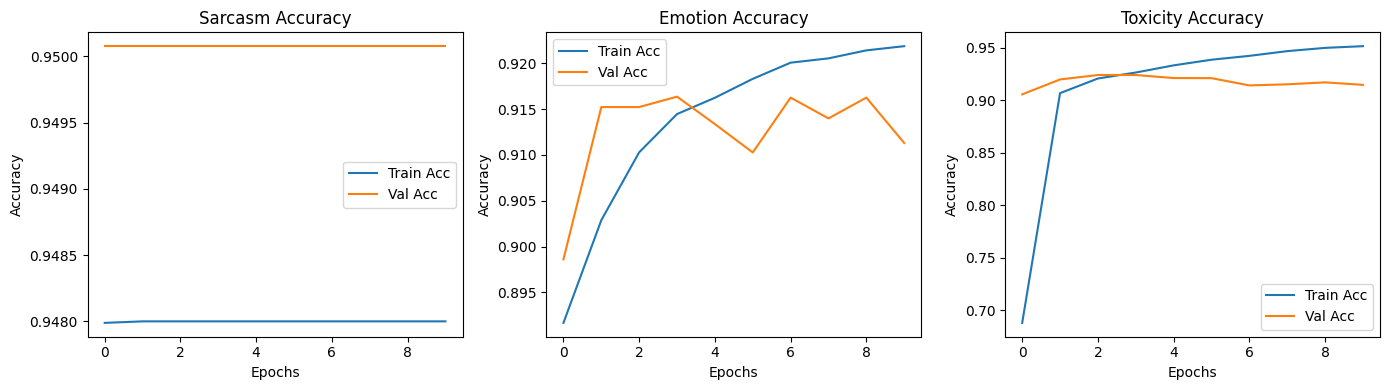

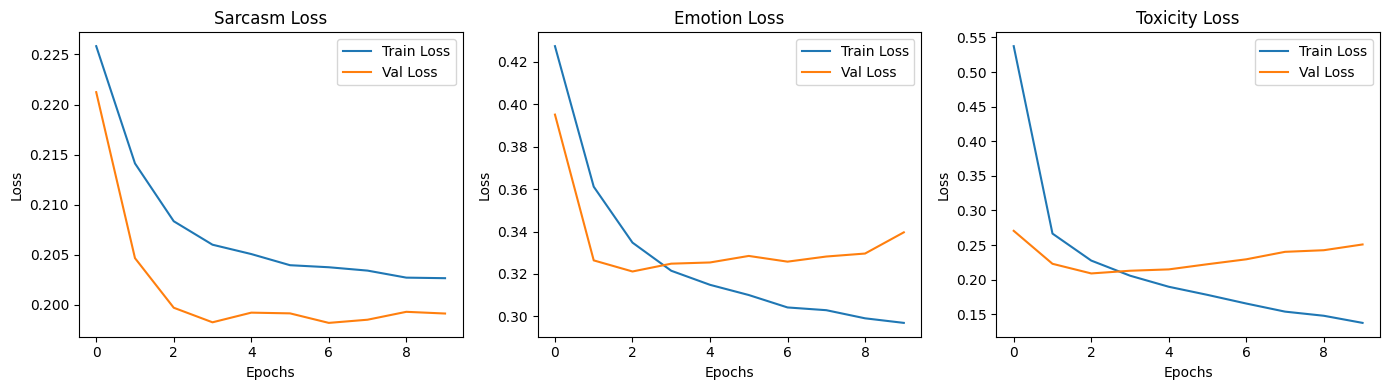

In [ ]:
import matplotlib.pyplot as plt

# Extract metrics from history
history_dict = history.history

# Sarcasm
plt.figure(figsize=(14,4))
plt.subplot(1,3,1)
plt.plot(history_dict['sarcasm_accuracy'], label='Train Acc')
plt.plot(history_dict['val_sarcasm_accuracy'], label='Val Acc')
plt.title('Sarcasm Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Emotion
plt.subplot(1,3,2)
plt.plot(history_dict['emotion_accuracy'], label='Train Acc')
plt.plot(history_dict['val_emotion_accuracy'], label='Val Acc')
plt.title('Emotion Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Toxicity
plt.subplot(1,3,3)
plt.plot(history_dict['toxicity_accuracy'], label='Train Acc')
plt.plot(history_dict['val_toxicity_accuracy'], label='Val Acc')
plt.title('Toxicity Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# --- Optional: Loss Plot ---
plt.figure(figsize=(14,4))
plt.subplot(1,3,1)
plt.plot(history_dict['sarcasm_loss'], label='Train Loss')
plt.plot(history_dict['val_sarcasm_loss'], label='Val Loss')
plt.title('Sarcasm Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,3,2)
plt.plot(history_dict['emotion_loss'], label='Train Loss')
plt.plot(history_dict['val_emotion_loss'], label='Val Loss')
plt.title('Emotion Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,3,3)
plt.plot(history_dict['toxicity_loss'], label='Train Loss')
plt.plot(history_dict['val_toxicity_loss'], label='Val Loss')
plt.title('Toxicity Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# Example comment from your dataset
example_comment = "Wow, that was really helpful… not!"

# Preprocess it using the same tokenizer and max_len
seq = tokenizer.texts_to_sequences([example_comment])
seq_pad = pad_sequences(seq, maxlen=50, padding='post')

# Predict using the trained model
sarcasm_pred, emotion_pred, toxicity_pred = complex_cnn.predict(seq_pad)

# Process outputs
sarcasm_label = "Sarcastic" if sarcasm_pred[0][0] > 0.5 else "Not Sarcastic"
emotion_label = le_emotion.inverse_transform([np.argmax(emotion_pred)])[0]
toxicity_label = "Toxic" if toxicity_pred[0][0] > 0.5 else "Not Toxic"

# Print results
print(f"Comment: {example_comment}")
print(f"Sarcasm: {sarcasm_label} (Score: {sarcasm_pred[0][0]:.2f})")
print(f"Emotion: {emotion_label} (Scores: {emotion_pred[0]})")
print(f"Toxicity: {toxicity_label} (Score: {toxicity_pred[0][0]:.2f})")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 622ms/step
Comment: Wow, that was really helpful… not!
Sarcasm: Not Sarcastic (Score: 0.07)
Emotion: neutral (Scores: [0.27192497 0.02083883 0.01246743 0.00185827 0.00458514 0.02495448
 0.04860528 0.01354974 0.01374299 0.58747286])
Toxicity: Not Toxic (Score: 0.01)


In [ ]:
# Example comment
example_comment = "Wow, that was really helpful… not!"

# Preprocess
seq = tokenizer.texts_to_sequences([example_comment])
seq_pad = pad_sequences(seq, maxlen=50, padding='post')

# Predict
sarcasm_pred, emotion_pred, toxicity_pred = complex_cnn.predict(seq_pad)

# --- Sarcasm ---
sarcasm_label = "Sarcastic" if sarcasm_pred[0][0] > 0.5 else "Not Sarcastic"
print(f"Sarcasm: {sarcasm_label} (Score: {sarcasm_pred[0][0]:.2f})")

# --- Toxicity ---
toxicity_label = "Toxic" if toxicity_pred[0][0] > 0.5 else "Not Toxic"
print(f"Toxicity: {toxicity_label} (Score: {toxicity_pred[0][0]:.2f})")

# --- Emotion ---
top3_idx = np.argsort(emotion_pred[0])[::-1][:3]   # indices of top-3 emotions
top3_scores = emotion_pred[0][top3_idx]
top3_labels = le_emotion.inverse_transform(top3_idx)

print("Top-3 Emotions:")
for lbl, score in zip(top3_labels, top3_scores):
    print(f"{lbl}: {score:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Sarcasm: Not Sarcastic (Score: 0.07)
Toxicity: Not Toxic (Score: 0.01)
Top-3 Emotions:
neutral: 0.59
Anger: 0.27
Neutral: 0.05


#Cell 1: Import Libraries

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, SpatialDropout1D, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Embedding, SpatialDropout1D, GaussianNoise,
                                     Bidirectional, LSTM, Dense, Dropout)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import plot_model

# --- MUStARD++ (Sarcasm + Emotion) ---
mustard_df = pd.read_csv("/content/mustard++_text.csv")
mustard_df = mustard_df[['SENTENCE', 'Sarcasm', 'Sarcasm_Type', 'Implicit_Emotion', 'Explicit_Emotion', 'Valence', 'Arousal']]
mustard_df['Sarcasm'] = mustard_df['Sarcasm'].fillna(0)
mustard_df['Explicit_Emotion'] = mustard_df['Explicit_Emotion'].fillna('neutral')

# --- Jigsaw (Toxicity + Metadata) ---
jigsaw_df = pd.read_csv("/content/data.csv")
jigsaw_df = jigsaw_df[['id','target','comment_text','severe_toxicity','obscene','identity_attack','insult','threat',
                       'asian','atheist','bisexual','black','buddhist','christian','female','heterosexual','hindu',
                       'homosexual_gay_or_lesbian','intellectual_or_learning_disability','jewish','latino','male',
                       'muslim','other_disability','other_gender','other_race_or_ethnicity','other_religion',
                       'other_sexual_orientation','physical_disability','psychiatric_or_mental_illness',
                       'transgender','white','created_date','publication_id','parent_id','article_id','rating',
                       'funny','wow','sad','likes','disagree','sexual_explicit','identity_annotator_count',
                       'toxicity_annotator_count']]

print("MUStARD++ sample:", mustard_df.head())
print("Jigsaw sample:", jigsaw_df.head())


MUStARD++ sample:                                             SENTENCE  Sarcasm Sarcasm_Type  \
0  Well, I'm sure that, uh, you...\nhave a lot of...      0.0          NaN   
1                                        Who was he?      0.0          NaN   
2    His name is Ron.\nI met him at my prayer group.      0.0          NaN   
3          How long have you been involved with him?      0.0          NaN   
4                                      A few months.      0.0          NaN   

  Implicit_Emotion Explicit_Emotion  Valence  Arousal  
0              NaN          neutral      NaN      NaN  
1              NaN          neutral      NaN      NaN  
2              NaN          neutral      NaN      NaN  
3              NaN          neutral      NaN      NaN  
4              NaN          neutral      NaN      NaN  
Jigsaw sample:        id    target                                       comment_text  \
0   59856  0.893617               haha you guys are a bunch of losers.   
1  239607  0.9

In [ ]:


def encode_labels(labels):
    le = LabelEncoder()
    return le.fit_transform(labels), le

def preprocess_texts(texts, tokenizer=None, max_len=50, num_words=20000):
    if tokenizer is None:
        tokenizer = Tokenizer(num_words=num_words, oov_token="<OOV>")
        tokenizer.fit_on_texts(texts)
    sequences = tokenizer.texts_to_sequences(texts)
    padded = pad_sequences(sequences, maxlen=max_len, padding='post')
    return padded, tokenizer

# --- MUStARD++ ---
X_mustard = mustard_df['SENTENCE'].astype(str).tolist()
y_sarcasm_m, le_sarcasm = encode_labels(mustard_df['Sarcasm'])
y_emotion_m, le_emotion = encode_labels(mustard_df['Explicit_Emotion'])
y_toxic_m = np.zeros(len(X_mustard))  # synthetic placeholder

# --- Jigsaw ---
X_jigsaw = jigsaw_df['comment_text'].astype(str).tolist()
y_toxic_j = (jigsaw_df['target'] > 0.5).astype(int).values

# Add synthetic sarcasm/emotion noise to Jigsaw
np.random.seed(42)
sarcasm_noise = np.random.choice([0,1], size=len(X_jigsaw), p=[0.95,0.05])
emotion_noise = np.random.choice([0,1], size=len(X_jigsaw), p=[0.95,0.05])

y_sarcasm_j = sarcasm_noise
y_emotion_j = emotion_noise

# Combine datasets
X_all = X_mustard + X_jigsaw
y_sarcasm_all = np.concatenate([y_sarcasm_m, y_sarcasm_j])
y_emotion_all = np.concatenate([y_emotion_m, y_emotion_j])
y_toxic_all = np.concatenate([y_toxic_m, y_toxic_j])

# Tokenize
X_seq, tokenizer = preprocess_texts(X_all, max_len=50)


In [ ]:

X_train, X_val, y_sarcasm_train, y_sarcasm_val, y_emotion_train, y_emotion_val, y_toxic_train, y_toxic_val = train_test_split(
    X_seq,
    y_sarcasm_all,
    y_emotion_all,
    y_toxic_all,
    test_size=0.1,
    random_state=42
)

y_train = {'sarcasm': y_sarcasm_train, 'emotion': y_emotion_train, 'toxicity': y_toxic_train}
y_val = {'sarcasm': y_sarcasm_val, 'emotion': y_emotion_val, 'toxicity': y_toxic_val}


In [ ]:

vocab_size = 20000
embedding_dim = 128
input_length = 50

inputs = Input(shape=(input_length,))
x = Embedding(vocab_size, embedding_dim, input_length=input_length)(inputs)
x = SpatialDropout1D(0.2)(x)
x = GaussianNoise(0.1)(x)

# BiLSTM Layer
x = Bidirectional(LSTM(128, return_sequences=False, kernel_regularizer=l2(0.001), dropout=0.3, recurrent_dropout=0.3))(x)

# Shared Dense Layers
dense1 = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
dense1 = Dropout(0.5)(dense1)
dense2 = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(dense1)
dense2 = Dropout(0.5)(dense2)

# Task-specific outputs
sarcasm_output = Dense(1, activation='sigmoid', name='sarcasm')(dense2)
emotion_output = Dense(len(le_emotion.classes_), activation='softmax', name='emotion')(dense2)
toxicity_output = Dense(1, activation='sigmoid', name='toxicity')(dense2)

# Build model
bilstm_model = Model(inputs=inputs, outputs=[sarcasm_output, emotion_output, toxicity_output])
bilstm_model.compile(
    optimizer='adam',
    loss={'sarcasm':'binary_crossentropy',
          'emotion':'sparse_categorical_crossentropy',
          'toxicity':'binary_crossentropy'},
    metrics={'sarcasm':'accuracy',
             'emotion':'accuracy',
             'toxicity':'accuracy'}
)

bilstm_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14      │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_16        │ (None, 50, 128)   │  2,560,000 │ input_layer_14[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_9 │ (None, 50, 128)   │          0 │ embedding_16[0][… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise_7    │ (None, 50, 128)   │          0 │ spatial_dropout1… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_9     │ (None, 256)       │    263,168 │ gaussian_noise_7… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 256)       │     65,792 │ bidirectional_9[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_39          │ (None, 256)       │          0 │ dense_23[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 128)       │     32,896 │ dropout_39[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_40          │ (None, 128)       │          0 │ dense_24[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sarcasm (Dense)     │ (None, 1)         │        129 │ dropout_40[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emotion (Dense)     │ (None, 10)        │      1,290 │ dropout_40[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ toxicity (Dense)    │ (None, 1)         │        129 │ dropout_40[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,923,404 (11.15 MB)

 Trainable params: 2,923,404 (11.15 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2727/2727 ━━━━━━━━━━━━━━━━━━━━ 868s 313ms/step - emotion_accuracy: 0.8850 - emotion_loss: 0.4782 - loss: 1.5068 - sarcasm_accuracy: 0.9446 - sarcasm_loss: 0.2341 - toxicity_accuracy: 0.6862 - toxicity_loss: 0.5548 - val_emotion_accuracy: 0.9073 - val_emotion_loss: 0.3347 - val_loss: 0.8700 - val_sarcasm_accuracy: 0.9501 - val_sarcasm_loss: 0.1985 - val_toxicity_accuracy: 0.9140 - val_toxicity_loss: 0.2320
Epoch 2/10
2727/2727 ━━━━━━━━━━━━━━━━━━━━ 851s 312ms/step - emotion_accuracy: 0.9048 - emotion_loss: 0.3495 - loss: 0.8989 - sarcasm_accuracy: 0.9486 - sarcasm_loss: 0.2085 - toxicity_accuracy: 0.9111 - toxicity_loss: 0.2497 - val_emotion_accuracy: 0.9135 - val_emotion_loss: 0.3209 - val_loss: 0.7988 - val_sarcasm_accuracy: 0.9501 - val_sarcasm_loss: 0.1981 - val_toxicity_accuracy: 0.9219 - val_toxicity_loss: 0.2190
Epoch 3/10
2727/2727 ━━━━━━━━━━━━━━━━━━━━ 858s 314ms/step - emotion_accuracy: 0.9126 - emotion_loss: 0.3276 - loss: 0.7999 - sarcasm_accuracy: 0.9477 - sarcasm_

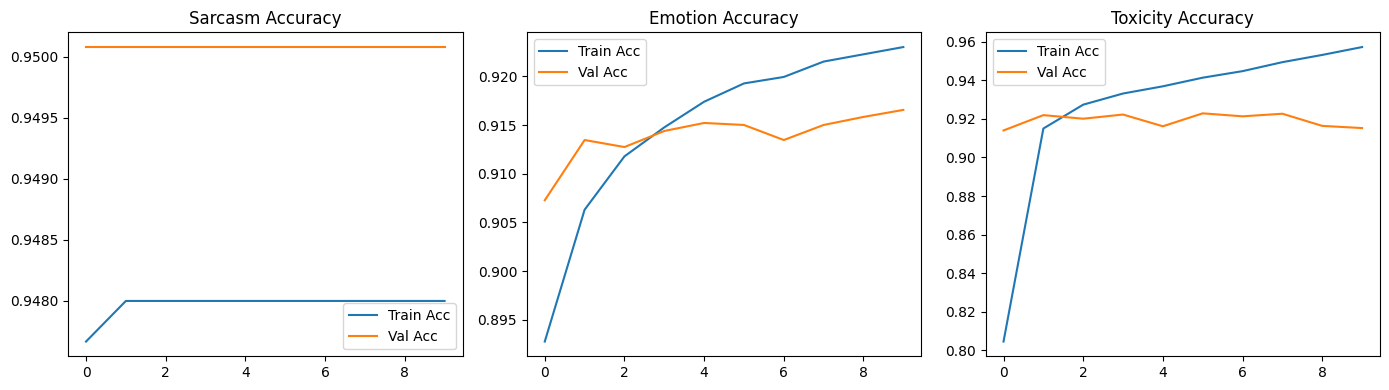

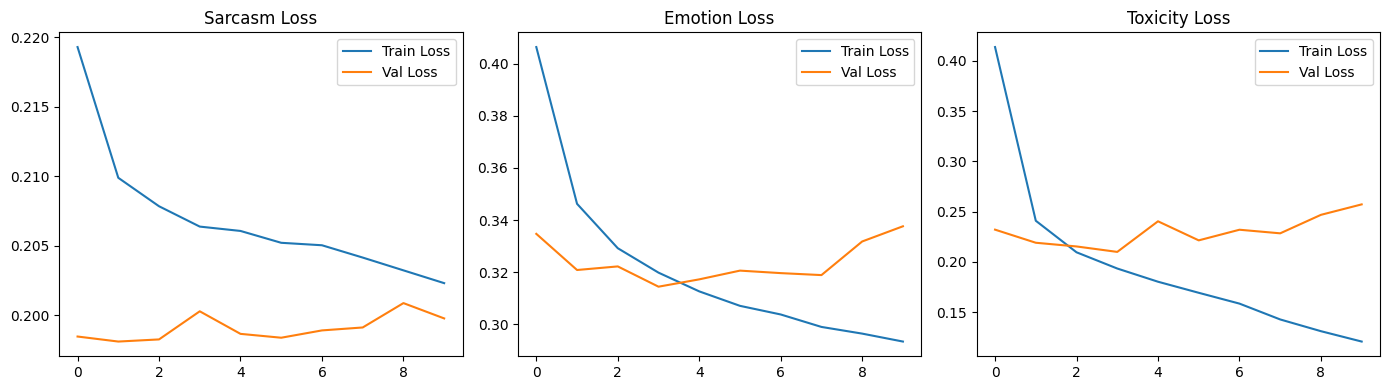

In [ ]:

history = bilstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

# Extract metrics
history_dict = history.history

# --- Accuracy Plots ---
plt.figure(figsize=(14,4))
plt.subplot(1,3,1)
plt.plot(history_dict['sarcasm_accuracy'], label='Train Acc')
plt.plot(history_dict['val_sarcasm_accuracy'], label='Val Acc')
plt.title('Sarcasm Accuracy'); plt.legend()

plt.subplot(1,3,2)
plt.plot(history_dict['emotion_accuracy'], label='Train Acc')
plt.plot(history_dict['val_emotion_accuracy'], label='Val Acc')
plt.title('Emotion Accuracy'); plt.legend()

plt.subplot(1,3,3)
plt.plot(history_dict['toxicity_accuracy'], label='Train Acc')
plt.plot(history_dict['val_toxicity_accuracy'], label='Val Acc')
plt.title('Toxicity Accuracy'); plt.legend()

plt.tight_layout()
plt.show()

# --- Loss Plots ---
plt.figure(figsize=(14,4))
plt.subplot(1,3,1)
plt.plot(history_dict['sarcasm_loss'], label='Train Loss')
plt.plot(history_dict['val_sarcasm_loss'], label='Val Loss')
plt.title('Sarcasm Loss'); plt.legend()

plt.subplot(1,3,2)
plt.plot(history_dict['emotion_loss'], label='Train Loss')
plt.plot(history_dict['val_emotion_loss'], label='Val Loss')
plt.title('Emotion Loss'); plt.legend()

plt.subplot(1,3,3)
plt.plot(history_dict['toxicity_loss'], label='Train Loss')
plt.plot(history_dict['val_toxicity_loss'], label='Val Loss')
plt.title('Toxicity Loss'); plt.legend()

plt.tight_layout()
plt.show()


In [ ]:

example_comment = "That's not what peruse means."

seq = tokenizer.texts_to_sequences([example_comment])
seq_pad = pad_sequences(seq, maxlen=50, padding='post')

sarcasm_pred, emotion_pred, toxicity_pred = bilstm_model.predict(seq_pad)

# Sarcasm
sarcasm_label = "Sarcastic" if sarcasm_pred[0][0] > 0.5 else "Not Sarcastic"
print(f"Sarcasm: {sarcasm_label} (Score: {sarcasm_pred[0][0]:.2f})")

# Toxicity
toxicity_label = "Toxic" if toxicity_pred[0][0] > 0.5 else "Not Toxic"
print(f"Toxicity: {toxicity_label} (Score: {toxicity_pred[0][0]:.2f})")

# Emotion (Top-3)
top3_idx = np.argsort(emotion_pred[0])[::-1][:3]
top3_scores = emotion_pred[0][top3_idx]
top3_labels = le_emotion.inverse_transform(top3_idx)

print("Top-3 Emotions:")
for lbl, score in zip(top3_labels, top3_scores):
    print(f"{lbl}: {score:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
Sarcasm: Not Sarcastic (Score: 0.07)
Toxicity: Not Toxic (Score: 0.01)
Top-3 Emotions:
Anger: 0.70
neutral: 0.20
Disgust: 0.05


#BiGRU Multi-task Model Code

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Embedding, SpatialDropout1D, GaussianNoise,
                                     Bidirectional, GRU, Dense, Dropout)
from tensorflow.keras.regularizers import l2

# --- MUStARD++ ---
mustard_df = pd.read_csv("/content/mustard++_text.csv")
mustard_df = mustard_df[['SENTENCE', 'Sarcasm', 'Sarcasm_Type', 'Implicit_Emotion', 'Explicit_Emotion', 'Valence', 'Arousal']]
mustard_df['Sarcasm'] = mustard_df['Sarcasm'].fillna(0)
mustard_df['Explicit_Emotion'] = mustard_df['Explicit_Emotion'].fillna('neutral')

# --- Jigsaw ---
jigsaw_df = pd.read_csv("/content/data.csv")
jigsaw_df = jigsaw_df[['id','target','comment_text','severe_toxicity','obscene','identity_attack','insult','threat',
                       'asian','atheist','bisexual','black','buddhist','christian','female','heterosexual','hindu',
                       'homosexual_gay_or_lesbian','intellectual_or_learning_disability','jewish','latino','male',
                       'muslim','other_disability','other_gender','other_race_or_ethnicity','other_religion',
                       'other_sexual_orientation','physical_disability','psychiatric_or_mental_illness',
                       'transgender','white','created_date','publication_id','parent_id','article_id','rating',
                       'funny','wow','sad','likes','disagree','sexual_explicit','identity_annotator_count',
                       'toxicity_annotator_count']]

print("MUStARD++ sample:", mustard_df.head())
print("Jigsaw sample:", jigsaw_df.head())


MUStARD++ sample:                                             SENTENCE  Sarcasm Sarcasm_Type  \
0  Well, I'm sure that, uh, you...\nhave a lot of...      0.0          NaN   
1                                        Who was he?      0.0          NaN   
2    His name is Ron.\nI met him at my prayer group.      0.0          NaN   
3          How long have you been involved with him?      0.0          NaN   
4                                      A few months.      0.0          NaN   

  Implicit_Emotion Explicit_Emotion  Valence  Arousal  
0              NaN          neutral      NaN      NaN  
1              NaN          neutral      NaN      NaN  
2              NaN          neutral      NaN      NaN  
3              NaN          neutral      NaN      NaN  
4              NaN          neutral      NaN      NaN  
Jigsaw sample:        id    target                                       comment_text  \
0   59856  0.893617               haha you guys are a bunch of losers.   
1  239607  0.9

In [ ]:

def encode_labels(labels):
    le = LabelEncoder()
    return le.fit_transform(labels), le

def preprocess_texts(texts, tokenizer=None, max_len=50, num_words=20000):
    if tokenizer is None:
        tokenizer = Tokenizer(num_words=num_words, oov_token="<OOV>")
        tokenizer.fit_on_texts(texts)
    sequences = tokenizer.texts_to_sequences(texts)
    padded = pad_sequences(sequences, maxlen=max_len, padding='post')
    return padded, tokenizer

# --- MUStARD++ ---
X_mustard = mustard_df['SENTENCE'].astype(str).tolist()
y_sarcasm_m, le_sarcasm = encode_labels(mustard_df['Sarcasm'])
y_emotion_m, le_emotion = encode_labels(mustard_df['Explicit_Emotion'])
y_toxic_m = np.zeros(len(X_mustard))  # placeholder

# --- Jigsaw ---
X_jigsaw = jigsaw_df['comment_text'].astype(str).tolist()
y_toxic_j = (jigsaw_df['target'] > 0.5).astype(int).values

# Synthetic sarcasm/emotion noise
np.random.seed(42)
sarcasm_noise = np.random.choice([0,1], size=len(X_jigsaw), p=[0.95,0.05])
emotion_noise = np.random.choice([0,1], size=len(X_jigsaw), p=[0.95,0.05])

y_sarcasm_j = sarcasm_noise
y_emotion_j = emotion_noise

# Combine
X_all = X_mustard + X_jigsaw
y_sarcasm_all = np.concatenate([y_sarcasm_m, y_sarcasm_j])
y_emotion_all = np.concatenate([y_emotion_m, y_emotion_j])
y_toxic_all = np.concatenate([y_toxic_m, y_toxic_j])

# Tokenize
X_seq, tokenizer = preprocess_texts(X_all, max_len=50)


In [ ]:

X_train, X_val, y_sarcasm_train, y_sarcasm_val, y_emotion_train, y_emotion_val, y_toxic_train, y_toxic_val = train_test_split(
    X_seq,
    y_sarcasm_all,
    y_emotion_all,
    y_toxic_all,
    test_size=0.1,
    random_state=42
)

y_train = {'sarcasm': y_sarcasm_train, 'emotion': y_emotion_train, 'toxicity': y_toxic_train}
y_val = {'sarcasm': y_sarcasm_val, 'emotion': y_emotion_val, 'toxicity': y_toxic_val}


In [ ]:

vocab_size = 20000
embedding_dim = 128
input_length = 50

inputs = Input(shape=(input_length,))
x = Embedding(vocab_size, embedding_dim, input_length=input_length)(inputs)
x = SpatialDropout1D(0.2)(x)
x = GaussianNoise(0.1)(x)

# 🔹 BiGRU Layer
x = Bidirectional(GRU(128, return_sequences=False, kernel_regularizer=l2(0.001), dropout=0.3, recurrent_dropout=0.3))(x)

# Shared Dense Layers
dense1 = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
dense1 = Dropout(0.5)(dense1)
dense2 = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(dense1)
dense2 = Dropout(0.5)(dense2)

# Task-specific outputs
sarcasm_output = Dense(1, activation='sigmoid', name='sarcasm')(dense2)
emotion_output = Dense(len(le_emotion.classes_), activation='softmax', name='emotion')(dense2)
toxicity_output = Dense(1, activation='sigmoid', name='toxicity')(dense2)

# Build model
bigru_model = Model(inputs=inputs, outputs=[sarcasm_output, emotion_output, toxicity_output])
bigru_model.compile(
    optimizer='adam',
    loss={'sarcasm':'binary_crossentropy',
          'emotion':'sparse_categorical_crossentropy',
          'toxicity':'binary_crossentropy'},
    metrics={'sarcasm':'accuracy',
             'emotion':'accuracy',
             'toxicity':'accuracy'}
)

bigru_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_17        │ (None, 50, 128)   │  2,560,000 │ input_layer_15[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_… │ (None, 50, 128)   │          0 │ embedding_17[0][… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise_8    │ (None, 50, 128)   │          0 │ spatial_dropout1… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_10    │ (None, 256)       │    198,144 │ gaussian_noise_8… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 256)       │     65,792 │ bidirectional_10… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_41          │ (None, 256)       │          0 │ dense_25[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 128)       │     32,896 │ dropout_41[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_42          │ (None, 128)       │          0 │ dense_26[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sarcasm (Dense)     │ (None, 1)         │        129 │ dropout_42[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emotion (Dense)     │ (None, 10)        │      1,290 │ dropout_42[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ toxicity (Dense)    │ (None, 1)         │        129 │ dropout_42[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,858,380 (10.90 MB)

 Trainable params: 2,858,380 (10.90 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2727/2727 ━━━━━━━━━━━━━━━━━━━━ 810s 293ms/step - emotion_accuracy: 0.8850 - emotion_loss: 0.4832 - loss: 1.4907 - sarcasm_accuracy: 0.9428 - sarcasm_loss: 0.2332 - toxicity_accuracy: 0.6912 - toxicity_loss: 0.5356 - val_emotion_accuracy: 0.9094 - val_emotion_loss: 0.3358 - val_loss: 0.8049 - val_sarcasm_accuracy: 0.9501 - val_sarcasm_loss: 0.2009 - val_toxicity_accuracy: 0.9224 - val_toxicity_loss: 0.2204
Epoch 2/10
2727/2727 ━━━━━━━━━━━━━━━━━━━━ 798s 291ms/step - emotion_accuracy: 0.9093 - emotion_loss: 0.3373 - loss: 0.8165 - sarcasm_accuracy: 0.9480 - sarcasm_loss: 0.2100 - toxicity_accuracy: 0.9203 - toxicity_loss: 0.2240 - val_emotion_accuracy: 0.9102 - val_emotion_loss: 0.3237 - val_loss: 0.7733 - val_sarcasm_accuracy: 0.9501 - val_sarcasm_loss: 0.1991 - val_toxicity_accuracy: 0.9246 - val_toxicity_loss: 0.2099
Epoch 3/10
2727/2727 ━━━━━━━━━━━━━━━━━━━━ 803s 294ms/step - emotion_accuracy: 0.9160 - emotion_loss: 0.3180 - loss: 0.7603 - sarcasm_accuracy: 0.9483 - sarcasm_

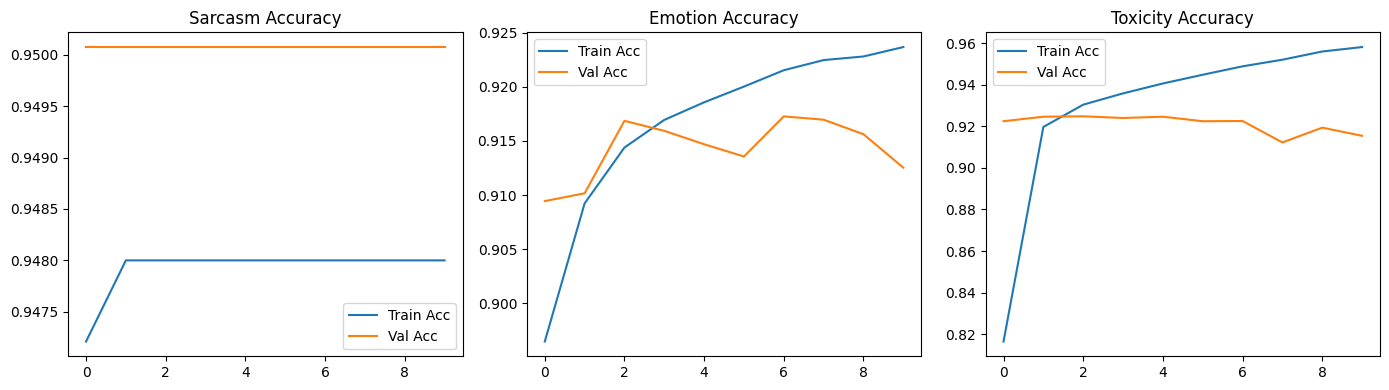

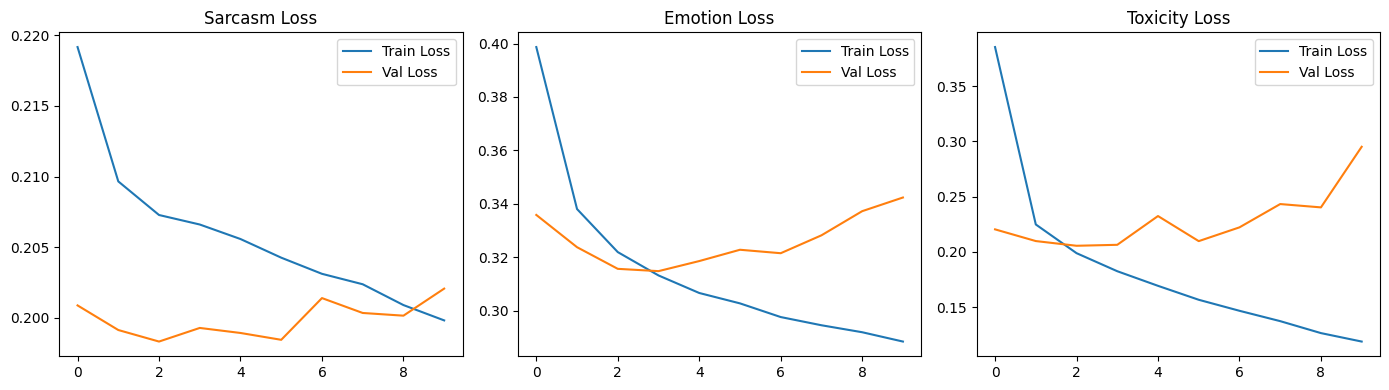

In [ ]:

history = bigru_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

# Extract metrics
history_dict = history.history

# Accuracy
plt.figure(figsize=(14,4))
plt.subplot(1,3,1)
plt.plot(history_dict['sarcasm_accuracy'], label='Train Acc')
plt.plot(history_dict['val_sarcasm_accuracy'], label='Val Acc')
plt.title('Sarcasm Accuracy'); plt.legend()

plt.subplot(1,3,2)
plt.plot(history_dict['emotion_accuracy'], label='Train Acc')
plt.plot(history_dict['val_emotion_accuracy'], label='Val Acc')
plt.title('Emotion Accuracy'); plt.legend()

plt.subplot(1,3,3)
plt.plot(history_dict['toxicity_accuracy'], label='Train Acc')
plt.plot(history_dict['val_toxicity_accuracy'], label='Val Acc')
plt.title('Toxicity Accuracy'); plt.legend()

plt.tight_layout(); plt.show()

# Loss
plt.figure(figsize=(14,4))
plt.subplot(1,3,1)
plt.plot(history_dict['sarcasm_loss'], label='Train Loss')
plt.plot(history_dict['val_sarcasm_loss'], label='Val Loss')
plt.title('Sarcasm Loss'); plt.legend()

plt.subplot(1,3,2)
plt.plot(history_dict['emotion_loss'], label='Train Loss')
plt.plot(history_dict['val_emotion_loss'], label='Val Loss')
plt.title('Emotion Loss'); plt.legend()

plt.subplot(1,3,3)
plt.plot(history_dict['toxicity_loss'], label='Train Loss')
plt.plot(history_dict['val_toxicity_loss'], label='Val Loss')
plt.title('Toxicity Loss'); plt.legend()

plt.tight_layout(); plt.show()


In [ ]:

example_comment = "Wow, that was really helpful… not!"

seq = tokenizer.texts_to_sequences([example_comment])
seq_pad = pad_sequences(seq, maxlen=50, padding='post')

sarcasm_pred, emotion_pred, toxicity_pred = bigru_model.predict(seq_pad)

# Sarcasm
sarcasm_label = "Sarcastic" if sarcasm_pred[0][0] > 0.5 else "Not Sarcastic"
print(f"Sarcasm: {sarcasm_label} (Score: {sarcasm_pred[0][0]:.2f})")

# Toxicity
toxicity_label = "Toxic" if toxicity_pred[0][0] > 0.5 else "Not Toxic"
print(f"Toxicity: {toxicity_label} (Score: {toxicity_pred[0][0]:.2f})")

# Emotion (Top-3)
top3_idx = np.argsort(emotion_pred[0])[::-1][:3]
top3_scores = emotion_pred[0][top3_idx]
top3_labels = le_emotion.inverse_transform(top3_idx)

print("Top-3 Emotions:")
for lbl, score in zip(top3_labels, top3_scores):
    print(f"{lbl}: {score:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Sarcasm: Not Sarcastic (Score: 0.09)
Toxicity: Not Toxic (Score: 0.01)
Top-3 Emotions:
neutral: 0.53
Anger: 0.28
Neutral: 0.06


In [ ]:
# CNN
complex_cnn.save("cnn_model.keras")

# BiLSTM
bilstm_model.save("bilstm_model.keras")

# BiGRU
bigru_model.save("bigru_model.keras")


In [ ]:
# --- Save models in .h5 format ---

# CNN
complex_cnn.save("cnn_model.h5")

# BiLSTM
bilstm_model.save("bilstm_model.h5")

# BiGRU
bigru_model.save("bigru_model.h5")


In [ ]:
from tensorflow.keras.models import load_model

# Load your trained BiGRU model
bigru_model = load_model("/content/bigru_model.h5")


In [ ]:
# Print all layers with their output shapes safely
for i, layer in enumerate(bigru_model.layers):
    try:
        print(i, layer.name, layer.output_shape)
    except AttributeError:
        # For InputLayer
        print(i, layer.name, getattr(layer, 'batch_input_shape', 'No shape'))


0 input_layer_15 No shape
1 embedding_17 No shape
2 spatial_dropout1d_10 No shape
3 gaussian_noise_8 No shape
4 bidirectional_10 No shape
5 dense_25 No shape
6 dropout_41 No shape
7 dense_26 No shape
8 dropout_42 No shape
9 sarcasm No shape
10 emotion No shape
11 toxicity No shape


In [ ]:
from tensorflow.keras.models import Model

# Create a new model that outputs the BiGRU embeddings
embedding_model = Model(inputs=bigru_model.input,
                        outputs=bigru_model.get_layer("bidirectional_10").output)

# Generate embeddings for your data
embeddings = embedding_model.predict(X_val, verbose=0)

print("Embeddings shape:", embeddings.shape)


Embeddings shape: (9695, 256)


In [ ]:
import numpy as np
np.save("bigru_behavior_embeddings.npy", embeddings)


In [ ]:
import numpy as np

# Load embeddings
embeddings = np.load("/content/bigru_behavior_embeddings.npy")
print("Embeddings shape:", embeddings.shape)  # (num_samples, 256)


Embeddings shape: (9695, 256)


In [ ]:
# CPU version
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu



Looking in indexes: https://download.pytorch.org/whl/cpu


In [ ]:
# Core PyG packages
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 8.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 29.1 MB/s eta 0:00:00
  Created wheel for torch-scatter: filename=torch_scatter-2.1.2-cp312-cp312-linux_x86_64.whl size=640889 sha256=47b713a308c53a5dae0f44ea0b81a2df2d0c34765c4da6f0ea1291612e3ebeaf
  Stored in directory: /root/.cache/pip/wheels/84/20/50/44800723f57cd798630e77b3ec83bc80bd26a1e3dc3a672ef5
  Created wheel for torch-sparse: filename=torch_sparse-0.6.18-cp312-cp312-linux_x86_64.whl size=1158903 sha256=264bc8baadaacba8ce10b3f8fc7600bdbef6acd1c